# Week 1 - Data Cleaning and Exploratory Analysis (EDA)
Dataset: Superstore Sales Dataset (Kaggle)

## 1. Data Loading and Preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("week1-task/data/superstore.csv", encoding="latin1")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'week1-task/data/superstore.csv'

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Q

In [3]:
print("Null values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Null values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


## 2. Handling Null Values

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

cat_cols = df.select_dtypes(include=["object"]).columns
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna("Unknown")

df.duplicated().sum()
df = df.drop_duplicates()
print("New shape:", df.shape)

New shape: (9994, 24)


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_648\2984343348.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


## 3. Outlier Detection

In [5]:
def iqr_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

sales_outliers = iqr_outliers("Sales")
profit_outliers = iqr_outliers("Profit")
print("Sales outliers:", len(sales_outliers))
print("Profit outliers:", len(profit_outliers))

Sales outliers: 1167
Profit outliers: 1881


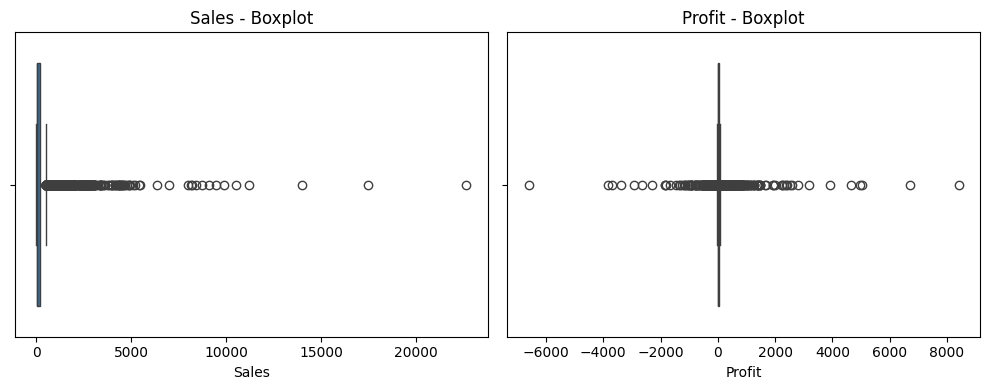

In [6]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(x=df["Sales"])
plt.title("Sales - Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df["Profit"])
plt.title("Profit - Boxplot")
plt.tight_layout()
plt.show()

Note: outliers were not removed, since they may represent real large orders or losses that carry meaningful business signal. They were only flagged for awareness during analysis.

## 4. Feature Engineering

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year

df["Profit Margin"] = df["Profit"] / df["Sales"]

df[["Order Date","Order Month","Order Year","Sales","Profit","Profit Margin"]].head()

,Order Date,Order Month,Order Year,Sales,Profit,Profit Margin
0,2016-11-08,11,2016,261.9600,41.9136,0.1600
1,2016-11-08,11,2016,731.9400,219.5820,0.3000
2,2016-06-12,6,2016,14.6200,6.8714,0.4700
3,2015-10-11,10,2015,957.5775,-383.0310,-0.4000
4,2015-10-11,10,2015,22.3680,2.5164,0.1125


## 5. Visualization

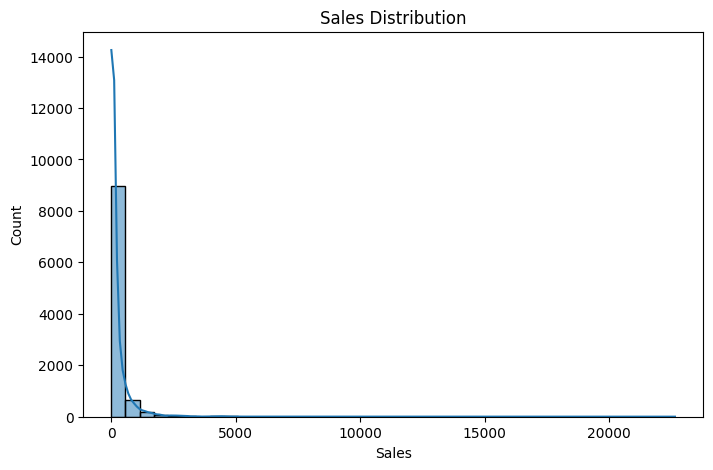

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=40, kde=True)
plt.title("Sales Distribution")
plt.show()

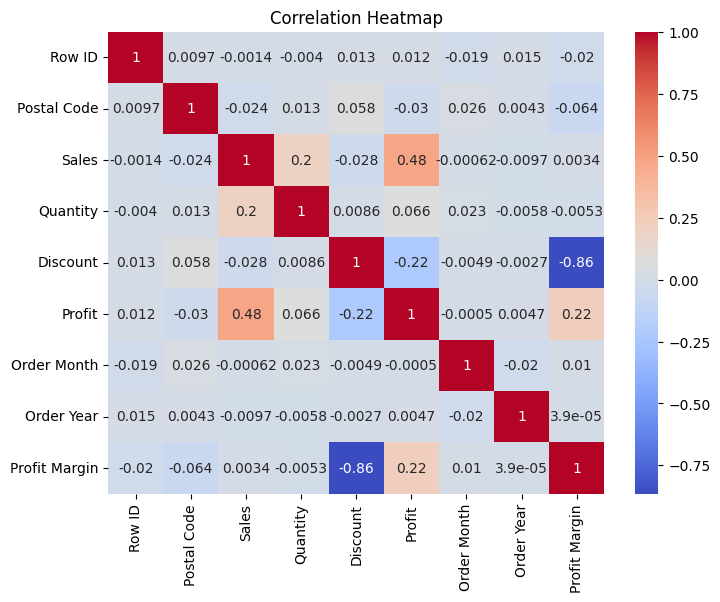

In [9]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

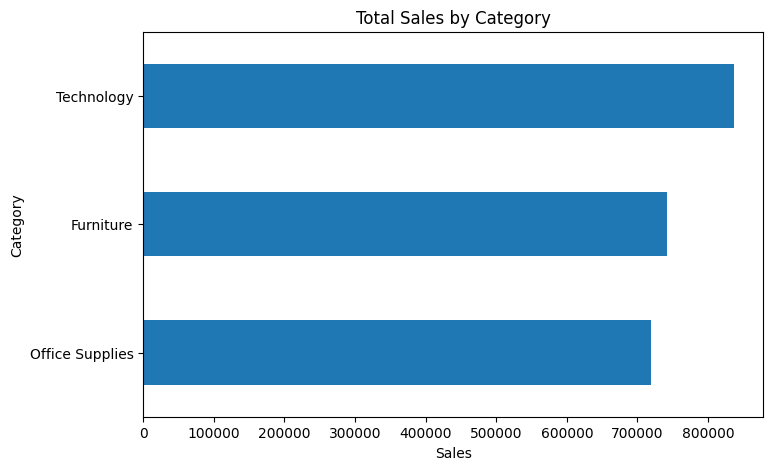

In [10]:
plt.figure(figsize=(8,5))
df.groupby("Category")["Sales"].sum().sort_values().plot(kind="barh")
plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.show()

## 6. Written Conclusion

1. There is a large gap between the best-selling and worst-selling categories.
2. Profit Margin is negative for some orders, meaning high discounts are causing losses.
3. Sales and Profit have a positive correlation, but it is not very strong - higher sales do not always mean higher profit.
4. Sales differ noticeably across regions, some regions are clearly more active.
5. Sales show seasonal patterns when grouped by Order Month.

## 7. Summary
This notebook covers the full EDA process on the Superstore dataset: data cleaning, outlier analysis, feature engineering, and visualization. All steps are reproducible and explained.